# * Statistic

In [11]:
import configparser
import datetime as dt
import pandas as pd
import numpy as np
import xlrd
import oracledb
import re

from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
import seaborn as sns

config = configparser.ConfigParser()
config.read('../../my_config.ini')
config.sections()

curr_dt = dt.datetime.now().date()
str_curr_dt = curr_dt.strftime('%Y%m%d')

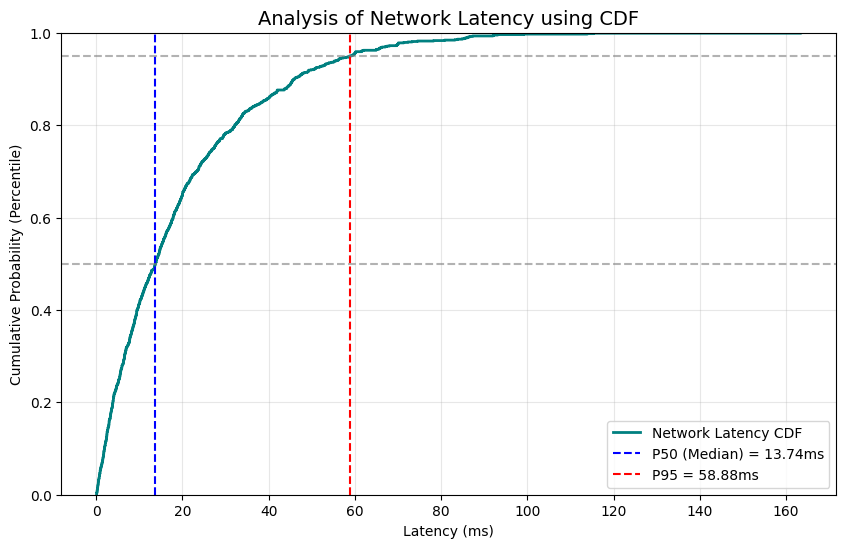

In [12]:
# 1. จำลองข้อมูล Latency (ms) - ส่วนใหญ่เร็ว แต่มีบางส่วนช้า (Exponential Distribution)
np.random.seed(42)
latency_data = np.random.exponential(scale=20, size=1000) 

# 2. คำนวณหาค่า Percentiles ที่สำคัญ
p50 = np.percentile(latency_data, 50)
p90 = np.percentile(latency_data, 90)
p95 = np.percentile(latency_data, 95)

# 3. พล็อตกราฟ ECDF (Empirical Cumulative Distribution Function)
plt.figure(figsize=(10, 6))
sns.ecdfplot(latency_data, label='Network Latency CDF', color='teal', linewidth=2)

# 4. ลากเส้นเพื่อแสดงตำแหน่ง Percentiles
plt.axhline(0.50, color='gray', linestyle='--', alpha=0.6)
plt.axvline(p50, color='blue', linestyle='--', label=f'P50 (Median) = {p50:.2f}ms')

plt.axhline(0.95, color='gray', linestyle='--', alpha=0.6)
plt.axvline(p95, color='red', linestyle='--', label=f'P95 = {p95:.2f}ms')

# ปรับแต่งกราฟ
plt.title('Analysis of Network Latency using CDF', fontsize=14)
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability (Percentile)')
plt.legend()
plt.grid(axis='both', alpha=0.3)
plt.show()